In [14]:
import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn

#RUN FOR ELEC
instance_len = 84030
num_instance = 370
num_numerical_features = 1
num_categorical_features = 0
categorical_features_per_class = [4, num_instance]
num_time_covariates = 0

In [4]:
#load elec df
df = pd.read_csv('../../data/LD2011_2014.txt', sep=";", index_col=0, parse_dates=True, decimal=',')
df = df.iloc[35040:] #remove times without data
df.fillna(0, inplace=True) #replace nans with 0s

In [5]:
df.head()

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
2012-01-01 00:15:00,3.807107,22.759602,77.324066,136.178862,70.731707,351.190476,9.609949,279.461279,75.174825,87.096774,...,128.479657,28500.0,1729.957806,1704.545455,15.645372,12.873025,504.828797,63.439065,761.730205,0.0
2012-01-01 00:30:00,5.076142,22.759602,77.324066,136.178862,73.170732,354.166667,9.044658,279.461279,73.426573,84.946237,...,127.765882,26400.0,1654.008439,1659.090909,15.645372,13.458163,525.021949,60.100167,702.346041,0.0
2012-01-01 00:45:00,3.807107,22.759602,77.324066,140.243902,69.512195,348.214286,8.479367,279.461279,75.174825,91.397849,...,114.204140,25200.0,1333.333333,1636.363636,15.645372,10.532475,526.777875,56.761269,696.480938,0.0
2012-01-01 01:00:00,3.807107,22.759602,77.324066,140.243902,75.609756,339.285714,7.348785,279.461279,68.181818,88.172043,...,112.062812,23800.0,1324.894515,1636.363636,15.645372,14.628438,539.947322,63.439065,693.548387,0.0
2012-01-01 01:15:00,5.076142,22.048364,77.324066,146.341463,73.170732,342.261905,6.783493,265.993266,69.930070,86.021505,...,112.776588,23700.0,1118.143460,1659.090909,15.645372,9.947338,556.628622,68.447412,723.607038,0.0


In [6]:
df.shape

(105216, 370)

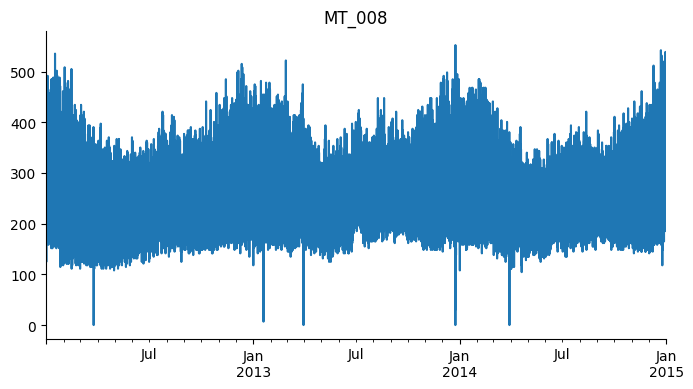

In [7]:
from matplotlib import pyplot as plt
df['MT_008'].plot(kind='line', figsize=(8, 4), title='MT_008')
plt.gca().spines[['top', 'right']].set_visible(False)

In [8]:
normalized_values=np.zeros((df.shape[0],df.shape[1]))

for i in range(df.shape[1]):
  temp_values = df.values[:, i]
  col_means = np.mean(temp_values, axis=0)
  col_stds = np.std(temp_values, axis=0)
  # print((temp_values - col_means) / col_stds)
  normalized_values[:, i] = ((temp_values - col_means) / col_stds)

In [9]:
normalized_values.shape

(105216, 370)

In [10]:
context_len = 672
pred_len = 96
window_size = context_len + pred_len
batch_size = 32
batch_window_start = np.random.randint(instance_len - window_size, size=batch_size)

In [11]:
batch_numerical_context = np.stack(
    [normalized_values[start_idx:start_idx + context_len] for start_idx in batch_window_start],
    axis=0).astype(np.float32)

# Reshape the batch_numerical_context to add the third dimension
batch_numerical_context = batch_numerical_context[:, :, np.newaxis]

In [12]:
batch_numerical_context.shape

(32, 672, 1, 370)